# Lab Segmentation 2

In [28]:
from commonfunctions import *
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.util import img_as_float, img_as_ubyte
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
# ==================== Experiment 1: Adaptive Thresholding ====================

def calculate_histogram(image):
    """
    Calculate histogram of a grayscale image.
    Returns counts array with 256 elements (one for each grey level 0-255)
    """
    # Ensure image is uint8
    if image.dtype != np.uint8:
        image = img_as_ubyte(image)
    
    # Initialize counts array
    counts = np.zeros(256, dtype=int)
    
    # Count pixels at each grey level
    for grey_level in range(256):
        counts[grey_level] = np.sum(image == grey_level)
    
    return counts
    

In [30]:
def getThreshold(image):
    """
    Calculate adaptive threshold using iterative mean-based algorithm.
    
    Args:
        image: Input grayscale image (can be float or uint8)
    
    Returns:
        threshold: The calculated threshold value
    """
    # Step 1: Convert image to uint8
    if image.dtype != np.uint8:
        image_uint8 = (image * 255).astype('uint8')
    else:
        image_uint8 = image.copy()
    
    # Step 2: Get counts array (histogram)
    counts = calculate_histogram(image_uint8)
    
    # Step 3: Get initial threshold (weighted average of all grey levels)
    grey_levels = np.arange(256)
    total_pixels = np.cumsum(counts)[-1]  # Total number of pixels
    
    # Calculate weighted mean: sum(grey_level * count) / total_pixels
    Tinit = round(np.sum(grey_levels * counts) / total_pixels)
    
    threshold = Tinit
    print(f"Initial threshold: {Tinit}")
    
    # Iterative refinement
    iteration = 0
    max_iterations = 100  # Safety limit
    
    while iteration < max_iterations:
        iteration += 1
        
        # Step 4: Calculate two weighted averages
        # Lower pixels (grey level < threshold)
        lower_range = list(range(0, threshold))
        lower_counts = counts[lower_range]
        total_lower_pixels = np.sum(lower_counts)
        
        if total_lower_pixels > 0:
            mean_lower = round(np.sum(np.array(lower_range) * lower_counts) / total_lower_pixels)
        else:
            mean_lower = 0
        
        # Higher pixels (grey level >= threshold)
        higher_range = list(range(threshold, 256))
        higher_counts = counts[higher_range]
        total_higher_pixels = np.sum(higher_counts)
        
        if total_higher_pixels > 0:
            mean_higher = round(np.sum(np.array(higher_range) * higher_counts) / total_higher_pixels)
        else:
            mean_higher = 255
        
        # Step 5: Update threshold (average of two means)
        new_threshold = round((mean_lower + mean_higher) / 2)
        
        # Step 6: Check for convergence
        if new_threshold == threshold:
            print(f"Converged after {iteration} iterations at threshold: {threshold}")
            break
        
        threshold = new_threshold
    
    return threshold

In [31]:
def apply_threshold(image, threshold):
    """
    Apply threshold to image: pixels < threshold = 0, pixels >= threshold = 255
    """
    # Convert to uint8 if needed
    if image.dtype != np.uint8:
        image_uint8 = (image * 255).astype('uint8')
    else:
        image_uint8 = image.copy()
    
    # Apply threshold
    binary_image = np.where(image_uint8 < threshold, 0, 255).astype('uint8')
    
    return binary_image

In [32]:
# ==================== Experiment 2: Local Adaptive Thresholding ====================

def local_adaptive_threshold(image):
    """
    Apply local adaptive thresholding by dividing image into 4 quarters.
    
    Args:
        image: Input grayscale image
    
    Returns:
        result: Image with local thresholds applied
    """
    # Convert to uint8 if needed
    if image.dtype != np.uint8:
        image_uint8 = (image * 255).astype('uint8')
    else:
        image_uint8 = image.copy()
    
    height, width = image_uint8.shape
    mid_h = height // 2
    mid_w = width // 2
    
    # Create result image
    result = np.zeros_like(image_uint8)
    
    # Process each quarter
    quarters = [
        (0, mid_h, 0, mid_w, "Top-Left"),
        (0, mid_h, mid_w, width, "Top-Right"),
        (mid_h, height, 0, mid_w, "Bottom-Left"),
        (mid_h, height, mid_w, width, "Bottom-Right")
    ]
    
    for h_start, h_end, w_start, w_end, name in quarters:
        quarter = image_uint8[h_start:h_end, w_start:w_end]
        print(f"\n{name} Quarter:")
        threshold = getThreshold(quarter)
        result[h_start:h_end, w_start:w_end] = apply_threshold(quarter, threshold)
    
    return result

In [33]:
# ==================== Main Execution ====================

def process_image(image_path, apply_local=False):
    """
    Process a single image with global and optionally local thresholding.
    """
    print(f"\n{'='*60}")
    print(f"Processing: {image_path}")
    print(f"{'='*60}")
    
    # Load image
    image = io.imread(image_path)
    
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = color.rgb2gray(image)
    
    # Ensure float format for processing
    image = img_as_float(image)
    
    # Calculate global threshold
    print("\nGlobal Thresholding:")
    global_threshold = getThreshold(image)
    global_result = apply_threshold(image, global_threshold)
    
    # Create figure
    if apply_local:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(image, cmap='gray')
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        axes[1].imshow(global_result, cmap='gray')
        axes[1].set_title(f'Global Threshold (T={global_threshold})')
        axes[1].axis('off')
        
        # Apply local thresholding
        print("\n" + "="*60)
        print("Local Adaptive Thresholding:")
        print("="*60)
        local_result = local_adaptive_threshold(image)
        
        axes[2].imshow(local_result, cmap='gray')
        axes[2].set_title('Local Adaptive Threshold')
        axes[2].axis('off')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(image, cmap='gray')
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        axes[1].imshow(global_result, cmap='gray')
        axes[1].set_title(f'Global Threshold (T={global_threshold})')
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"output_{image_path.split('/')[-1]}", dpi=150, bbox_inches='tight')
    plt.show()


EXPERIMENT 1: Global Adaptive Thresholding

Processing: cameraman.png

Global Thresholding:
Initial threshold: 119
Converged after 6 iterations at threshold: 88


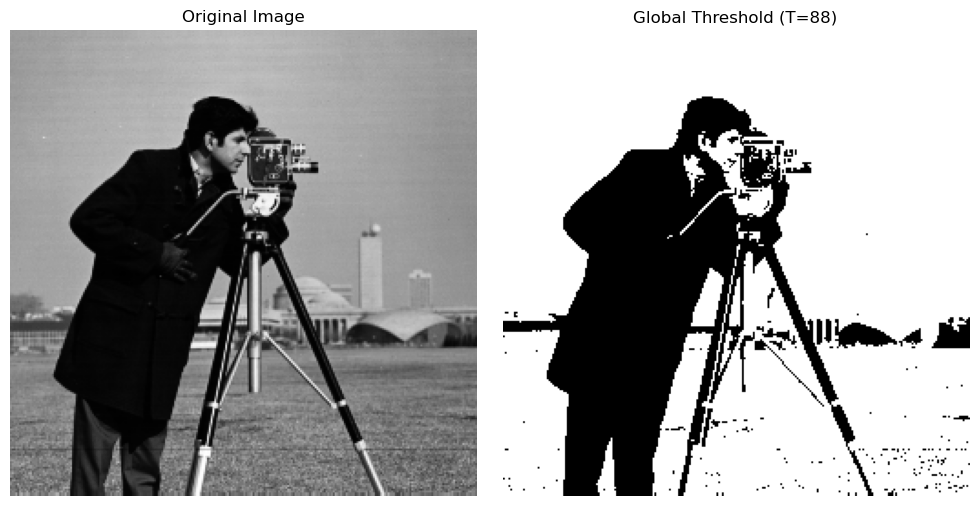


Processing: cufe.png

Global Thresholding:
Initial threshold: 165
Converged after 4 iterations at threshold: 142


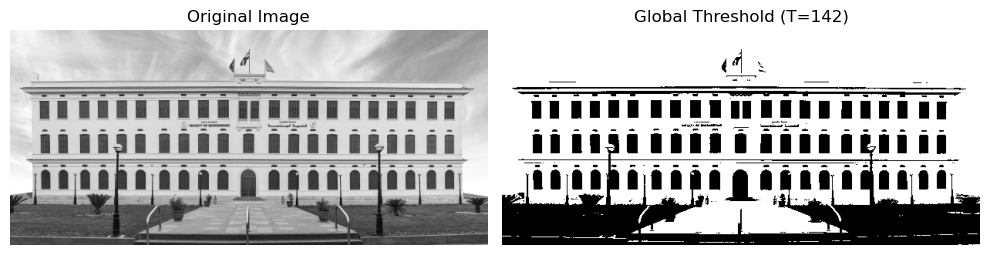


Processing: book1.png

Global Thresholding:
Initial threshold: 156
Converged after 5 iterations at threshold: 143


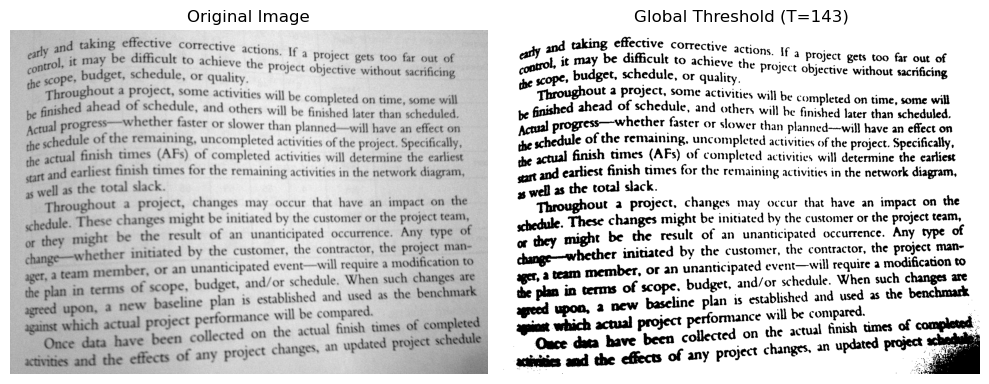


Processing: book.png

Global Thresholding:
Initial threshold: 128
Converged after 3 iterations at threshold: 138


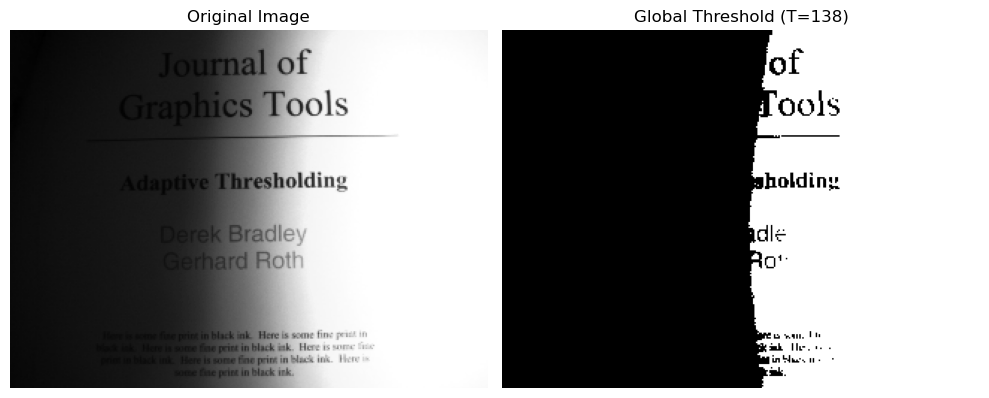


EXPERIMENT 2: Local Adaptive Thresholding on book.png

Processing: book.png

Global Thresholding:
Initial threshold: 128
Converged after 3 iterations at threshold: 138

Local Adaptive Thresholding:

Top-Left Quarter:
Initial threshold: 27
Converged after 6 iterations at threshold: 46

Top-Right Quarter:
Initial threshold: 224
Converged after 4 iterations at threshold: 186

Bottom-Left Quarter:
Initial threshold: 32
Converged after 5 iterations at threshold: 50

Bottom-Right Quarter:
Initial threshold: 230
Converged after 5 iterations at threshold: 196


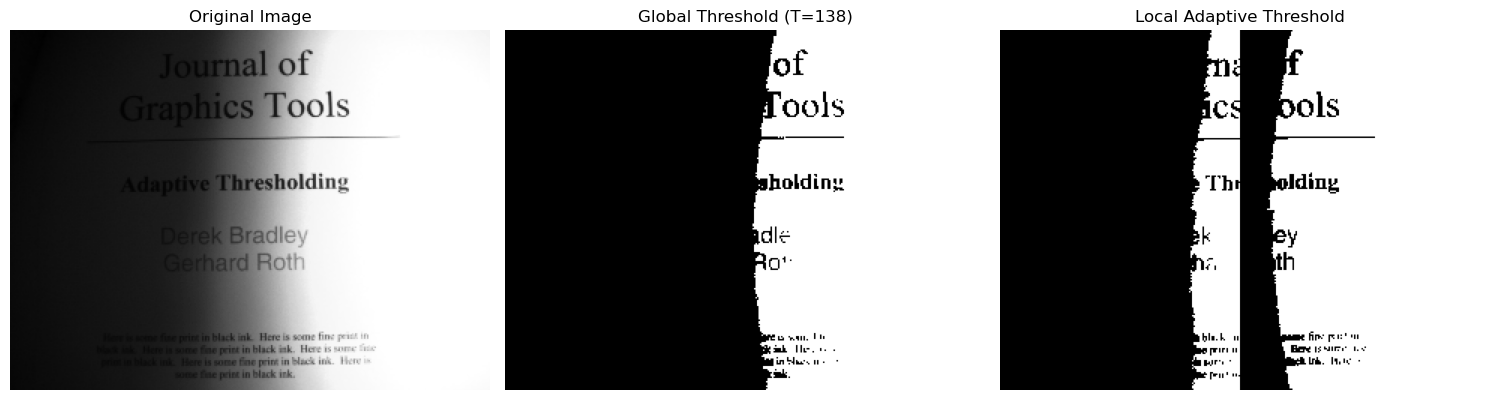


All experiments completed!


In [34]:
# ==================== Run Experiments ====================

if __name__ == "__main__":
    # Experiment 1: Test on multiple images
    print("\n" + "="*60)
    print("EXPERIMENT 1: Global Adaptive Thresholding")
    print("="*60)
    
    test_images = ["cameraman.png", "cufe.png", 
                   "book1.png", "book.png"]
    
    for img_path in test_images:
        try:
            process_image(img_path, apply_local=False)
        except FileNotFoundError:
            print(f"Image not found: {img_path}")
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
    
    # Experiment 2: Local adaptive thresholding on book.png
    print("\n" + "="*60)
    print("EXPERIMENT 2: Local Adaptive Thresholding on book.png")
    print("="*60)
    
    try:
        process_image("book.png", apply_local=True)
    except FileNotFoundError:
        print("Image not found: book.png")
    except Exception as e:
        print(f"Error processing book.png: {e}")
    
    print("\n" + "="*60)
    print("All experiments completed!")
    print("="*60)

In [35]:
def improved_local_threshold_overlapping(image, block_size=64, overlap=0.5):
    """
    Improved local thresholding with overlapping blocks and weighted averaging.
    
    Justification:
    - Overlapping blocks reduce boundary artifacts
    - Weighted averaging creates smooth transitions between regions
    - Smaller blocks adapt better to local variations
    
    Args:
        image: Input grayscale image
        block_size: Size of each block (default: 64)
        overlap: Overlap ratio between blocks (0-1, default: 0.5)
    
    Returns:
        Binary image with improved local thresholding
    """
    if image.dtype != np.uint8:
        image_uint8 = (image * 255).astype('uint8')
    else:
        image_uint8 = image.copy()
    
    height, width = image_uint8.shape
    step_size = int(block_size * (1 - overlap))
    
    # Create weight matrix for blending
    weight_matrix = np.zeros((height, width), dtype=float)
    result_sum = np.zeros((height, width), dtype=float)
    
    print(f"Processing with block_size={block_size}, overlap={overlap}")
    
    block_count = 0
    for i in range(0, height - block_size + 1, step_size):
        for j in range(0, width - block_size + 1, step_size):
            # Extract block
            block = image_uint8[i:i+block_size, j:j+block_size]
            
            # Calculate threshold for this block
            threshold = getThreshold(block)
            binary_block = apply_threshold(block, threshold)
            
            # Create weight for this block (Gaussian-like)
            y, x = np.ogrid[0:block_size, 0:block_size]
            center_y, center_x = block_size // 2, block_size // 2
            weight = np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * (block_size/4)**2))
            
            # Accumulate results
            result_sum[i:i+block_size, j:j+block_size] += binary_block * weight
            weight_matrix[i:i+block_size, j:j+block_size] += weight
            
            block_count += 1
    
    print(f"Processed {block_count} overlapping blocks")
    
    # Normalize by weights
    result = np.zeros_like(image_uint8)
    valid_mask = weight_matrix > 0
    result[valid_mask] = (result_sum[valid_mask] / weight_matrix[valid_mask]).astype('uint8')
    
    # Apply final threshold to ensure binary output
    result = np.where(result >= 128, 255, 0).astype('uint8')
    
    return result

In [36]:
def morphological_improvement(binary_image, operation='close', kernel_size=3):
    """
    Apply morphological operations to improve binary image quality.
    
    Justification:
    - Removes small noise (opening)
    - Fills small holes (closing)
    - Smooths boundaries
    
    Args:
        binary_image: Binary input image
        operation: 'open', 'close', or 'both'
        kernel_size: Size of structuring element
    
    Returns:
        Improved binary image
    """
    kernel = morphology.disk(kernel_size)
    
    if operation == 'open':
        result = morphology.opening(binary_image, kernel)
    elif operation == 'close':
        result = morphology.closing(binary_image, kernel)
    elif operation == 'both':
        # Apply opening then closing
        result = morphology.opening(binary_image, kernel)
        result = morphology.closing(result, kernel)
    else:
        result = binary_image
    
    return result

In [37]:
def adaptive_gaussian_threshold(image, block_size=35, C=2):
    """
    Adaptive thresholding using local Gaussian-weighted mean.
    
    Justification:
    - Adapts to local illumination variations
    - Gaussian weighting reduces sensitivity to noise
    - Better for documents with uneven lighting
    
    Args:
        image: Input grayscale image
        block_size: Size of neighborhood (must be odd)
        C: Constant subtracted from mean
    
    Returns:
        Binary image
    """
    if image.dtype != np.uint8:
        image_uint8 = (image * 255).astype('uint8')
    else:
        image_uint8 = image.copy()
    
    # Apply Gaussian filter to get local mean
    local_mean = ndimage.gaussian_filter(image_uint8.astype(float), 
                                         sigma=block_size/6)
    
    # Threshold: pixel > (local_mean - C)
    result = np.where(image_uint8 > (local_mean - C), 255, 0).astype('uint8')
    
    return result

In [38]:
def otsu_threshold(image):
    """
    Otsu's automatic thresholding method.
    
    Justification:
    - Optimal threshold for bimodal histograms
    - No parameters needed
    - Maximizes between-class variance
    
    Args:
        image: Input grayscale image
    
    Returns:
        threshold_value: Calculated threshold
        binary_image: Thresholded image
    """
    if image.dtype != np.uint8:
        image_uint8 = (image * 255).astype('uint8')
    else:
        image_uint8 = image.copy()
    
    # Use scikit-image's Otsu implementation
    threshold_value = filters.threshold_otsu(image_uint8)
    binary_image = np.where(image_uint8 >= threshold_value, 255, 0).astype('uint8')
    
    return threshold_value, binary_image

In [39]:
def compare_methods(image_path):
    """
    Compare multiple thresholding methods on a single image.
    """
    print(f"\n{'='*60}")
    print(f"Comparing Methods: {image_path}")
    print(f"{'='*60}")
    
    # Load image
    image = io.imread(image_path)
    if len(image.shape) == 3:
        image = color.rgb2gray(image)
    image = img_as_float(image)
    
    # Method 1: Basic global threshold
    print("\n1. Basic Global Threshold:")
    t1 = getThreshold(image)
    result1 = apply_threshold(image, t1)
    
    # Method 2: Basic local threshold (4 quarters)
    print("\n2. Basic Local Threshold (4 quarters):")
    from segmentation_lab import local_adaptive_threshold
    result2 = local_adaptive_threshold(image)
    
    # Method 3: Improved overlapping blocks
    print("\n3. Overlapping Blocks:")
    result3 = improved_local_threshold_overlapping(image, block_size=64, overlap=0.5)
    
    # Method 4: Otsu's method
    print("\n4. Otsu's Method:")
    t4, result4 = otsu_threshold(image)
    print(f"Otsu threshold: {t4}")
    
    # Method 5: Adaptive Gaussian
    print("\n5. Adaptive Gaussian:")
    result5 = adaptive_gaussian_threshold(image, block_size=35, C=2)
    
    # Method 6: Morphological improvement on method 3
    print("\n6. Overlapping + Morphology:")
    result6 = morphological_improvement(result3, operation='both', kernel_size=2)
    
    # Display results
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    axes[0, 0].imshow(image, cmap='gray')
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(result1, cmap='gray')
    axes[0, 1].set_title(f'Global (T={t1})')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(result2, cmap='gray')
    axes[0, 2].set_title('Local (4 quarters)')
    axes[0, 2].axis('off')
    
    axes[0, 3].imshow(result3, cmap='gray')
    axes[0, 3].set_title('Overlapping Blocks')
    axes[0, 3].axis('off')
    
    axes[1, 0].imshow(result4, cmap='gray')
    axes[1, 0].set_title(f'Otsu (T={t4})')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(result5, cmap='gray')
    axes[1, 1].set_title('Adaptive Gaussian')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(result6, cmap='gray')
    axes[1, 2].set_title('Overlap + Morphology')
    axes[1, 2].axis('off')
    
    axes[1, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"comparison_{image_path.split('/')[-1]}", dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'global': result1,
        'local_4': result2,
        'overlapping': result3,
        'otsu': result4,
        'gaussian': result5,
        'morphology': result6
    }

In [40]:
# ==================== Main Execution ====================

if __name__ == "__main__":
    print("\n" + "="*60)
    print("EXPERIMENT 3 (BONUS): Improved Thresholding Methods")
    print("="*60)
    
    # Test on book.png (most challenging)
    try:
        results = compare_methods("book.png")
        
        print("\n" + "="*60)
        print("RECOMMENDATIONS:")
        print("="*60)
        print("""
        Best methods for different scenarios:
        
        1. DOCUMENTS with uneven lighting (like book.png):
           → Overlapping Blocks or Adaptive Gaussian
           → These methods adapt to local illumination
        
        2. CLEAN images with uniform lighting:
           → Global Threshold or Otsu's Method
           → Faster and simpler
        
        3. NOISY images:
           → Add Morphological operations (closing/opening)
           → Removes small artifacts
        
        4. GENERAL purpose:
           → Overlapping Blocks + Morphology
           → Best balance of quality and robustness
        """)
        
    except FileNotFoundError:
        print("Image not found: images/book.png")
    except Exception as e:
        print(f"Error: {e}")
    
    print("\n" + "="*60)
    print("Bonus experiment completed!")
    print("="*60)


EXPERIMENT 3 (BONUS): Improved Thresholding Methods

Comparing Methods: book.png

1. Basic Global Threshold:
Initial threshold: 128
Converged after 3 iterations at threshold: 138

2. Basic Local Threshold (4 quarters):
Error: No module named 'segmentation_lab'

Bonus experiment completed!
